# **12 · 원자료 재검증 — 파이프라인의 숫자는 공식 통계의 숫자인가 (전 셀 대조)**

### **"언론 인식 배터리 5종(2019·2020)·뉴스 전반 신뢰 평균/비율(2023~2025)·`cred_mean` 7개년이 공식 보고서와 반올림 자리까지 전 셀 일치 — 2019→2020 계단은 하모나이즈 인공물이 아니라 공식 통계의 실재이며, 남는 것은 원인 귀속뿐이다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = `.sav` 원자료 7개년(원척도 1~5 · **연도별 공식 가중치**) ↔ KPF 공식 보고서 통계표 · 방법 = **전 셀 대조 + 가설 배제**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **① 데이터 파악(원전 검증)** + **⑤ 평가(게이트 해소)** · CRISP-DM **P2·P5** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 하모나이즈 파이프라인(변수 매핑·특수코드 처리·가중치 적용)은 KPF **공식 보고서 통계표를 정확히 재현**하는가 — 몇 셀이나, 어느 자리까지?
> **Q2.** 정렬추세의 절반을 차지하는 **2019→2020 계단(+0.354 SD)**은 하모나이즈·모형의 인공물인가, 공식 통계에 실재하는가 — 어떤 가설이 원자료 수준에서 배제되는가?
> **Q3.** 이 재검증은 **인용 자격등급**(30 DB③ 4층)을 어떻게 바꾸는가 — 무엇이 승격되고 무엇이 '방향만'으로 남는가?

## **이 노트북의 위상 — 분석이 아니라 분석의 '원전 감사'다**

`11`이 7개년을 결합했고 `20`~`24`가 그 위에서 추세를 세웠다면, 12는 그 토대(파이프라인 신뢰성)를 **1차 원전(공식 보고서 공표치)**과 직접 대조한다. 이 노트북이 무너지면 이후의 모든 수치가 "잘못 읽은 원자료의 정교한 분석"이 된다 — 그래서 재검증은 P6 보고서 착수의 선행 게이트였고, 2026-07-11에 해소됐다.

- **로직 SSOT(thin import)**: [`src/kpf_revalidation.py`](../src/kpf_revalidation.py) — §A 절대수준·§B 계단 진단·§C 재현 대조. `harmonize.py`의 매핑·재코딩을 그대로 import(재구현 금지). 가중은 `wt_year_eq`가 아니라 **연도별 공식 가중치**(2019 `wt1` · 이후 `WT`/`HMWT`)다 — 공표치와 같은 정의로 재계산해야 대조가 성립한다.
- **판정 문서(SSOT)**: [`docs/design/kpf-revalidation.md`](../docs/design/kpf-revalidation.md) — 본 노트북 §번호는 이 문서 §1·§2와 대응. 대조 원전 = 2019 보고서 그림 2-104(p.86) · 2020 그림 4-117(p.124)·표 3-1(p.45)·p.28 · 2025 그림 1-20(p.30)·p.17(로컬 PDF, git 미포함).
- **후속 반영**: 이 판정이 [`p6-pdf-structure.md`](../docs/report/p6-pdf-structure.md) §3 인용 수치표(자격등급)의 근거이며, `10`·`11`·`20`~`30`의 게이트 문구가 "해소됨"으로 갱신된 근거다.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 무엇과 대조해야 '검증'인가 — **Decision Box ①** | — |
| 2 | [실행] A. 신뢰 절대수준 — 원척도·공식 가중 재계산 ↔ 공표치 | 대조표 + assert |
| 3 | [실행] B. 2019→2020 계단 진단 — 라벨 원문·분포 이동·가중치 민감도 + [시각화] + **Decision Box ②** | 진단표 + figure |
| 4 | [실행] C. 파이프라인 재현 대조 — `cred_mean` 7개년 ±0.001 | PASS |
| 5 | [입증] 검증 셀 — 공표치 전 셀 assert + 자격등급 갱신표 | 전 셀 PASS |
| 6 | 종합 — 연구질문 답·게이트 해소·다음 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import kpf_revalidation as R      # SSOT — 재검증 로직(재구현 금지)
import harmonize as hz

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

print(f"대상 연도 = {R.YEARS}")
print(f"공식 가중치 변수 = {hz.WEIGHT_BY_YEAR}")
print(f"파이프라인 기준값(eda-overview §1-③) cred_mean = {R.PIPELINE_CRED_MEAN}")
print(f"CSV 산출 경로(gitignore, 재생성물) = {R.OUT_DIR.relative_to(ROOT)}")

대상 연도 = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
공식 가중치 변수 = {2019: 'wt1', 2020: 'WT', 2021: 'WT', 2022: 'WT', 2023: 'HMWT', 2024: 'WT', 2025: 'WT'}
파이프라인 기준값(eda-overview §1-③) cred_mean = {2019: 3.034, 2020: 3.249, 2021: 3.305, 2022: 3.211, 2023: 3.19, 2024: 3.176, 2025: 3.39}
CSV 산출 경로(gitignore, 재생성물) = data\interim\revalidation


## **1. [전제] 무엇과 대조해야 '검증'인가 — 대조 원전의 선택**

"파이프라인이 옳다"는 주장은 파이프라인 내부에서 증명할 수 없다(자기 채점). 외부 기준이 필요하고, 그 기준의 자격이 판정의 자격을 결정한다.

### **Decision Box ① — 대조 기준: 왜 공식 보고서 공표치인가**

**기준: 파이프라인 산출의 정오를 무엇으로 판정하는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 파이프라인 내부 일관성 | 결합 전후 행수·범위·NA 검사만 | ❌ 필요조건일 뿐(이미 `11` §4에서 수행) — 변수를 **잘못 매핑해도** 내부 검사는 통과한다 |
| (b) 외부 조사(로이터 DNR 등) 대조 | 국제 조사의 한국 신뢰 수치와 비교 | ❌ 문항·척도·모집단·조사방식이 달라 수치 일치를 기대할 수 없음 — 방향 참고용(각주)으로만 |
| (c) **KPF 공식 보고서 공표치 대조** | 같은 원자료로 조사기관이 공표한 통계표와 **전 셀 대조** | ✅ **채택** — 같은 데이터·같은 가중치 정의이므로 **반올림 자리까지 일치해야 정상**. 불일치는 곧 매핑·재코딩·가중 오류의 검출기 |

**전 셀 일치의 의미**: 배터리 5문항 × 2개년 + 전반/이용 신뢰(평균·비율) × 3개년 = 대조한 모든 셀이 일치하면, "변수 매핑·특수코드·가중치 적용"이라는 파이프라인의 3대 오류원이 동시에 원전 수준에서 배제된다.

## **2. [실행] A. 신뢰 절대수준 — 원척도·공식 가중 재계산**

`R.section_a_levels()`가 연도별 `.sav`를 로드해 **원척도(1~5, 무응답 특수코드 제외)·공식 가중치**로 단일문항(뉴스 전반 신뢰)과 credibility 핵심3·`cred_mean`의 가중평균, '신뢰한다'(4~5점) 비율을 재계산한다. 아래 표가 kpf-revalidation §1.2 대조의 재계산 쪽 원본이다(공표치와의 assert는 §5 검증 셀에서 일괄).

In [2]:
levels = R.section_a_levels()      # 7개년 .sav 로드 — 수십 초~수 분
cols = ["year", "N", "overall_src", "overall_mean_wt", "overall_pct45_wt",
        "cred_fair_mean_wt", "cred_professional_mean_wt", "cred_accurate_mean_wt",
        "cred_mean_wt"]
levels[cols]

,year,N,overall_src,overall_mean_wt,overall_pct45_wt,cred_fair_mean_wt,cred_professional_mean_wt,cred_accurate_mean_wt,cred_mean_wt
0,2019,5040,NaN,NaN,NaN,2.807,3.340,2.956,3.034
1,2020,5010,Q79_10,3.297,40.3,3.052,3.503,3.193,3.249
2,2021,5010,Q81_10,3.322,42.8,3.118,3.551,3.248,3.305
3,2022,58936,Q72_10,3.151,32.0,3.065,3.359,3.209,3.211
4,2023,5000,Q79_1,3.272,37.8,3.036,3.373,3.160,3.190
5,2024,6000,Q79_1,3.360,45.5,3.081,3.339,3.109,3.176
6,2025,6000,Q87_1,3.436,49.0,3.205,3.579,3.386,3.390


**관찰**: 뉴스 전반 신뢰(단일문항)는 2023 3.272 → 2024 3.360 → 2025 3.436으로, 공표치(3.27/3.36/3.44)의 반올림 전 값이 그대로 나온다. '신뢰한다' 비율(37.8/45.5/49.0%)도 소수 첫째 자리까지 동일하다. 2019는 단일문항이 구조적으로 부재(`overall_src` 없음)한 연도라는 점도 재확인된다 — `23` DB③의 "2019 기준연도 의존성" 주의가 데이터 구조에서 나오는 이유다.

## **3. [실행] B. 2019→2020 계단 진단 — 인공물 가설의 전수 배제**

계단(+0.354 SD)이 파이프라인 인공물이려면 어딘가에 조작점이 있어야 한다: 문항 워딩이 바뀌었거나, 척도·특수코드가 오독됐거나, 가중치가 다르게 걸렸거나. `R.section_b_step()`이 세 가설을 원자료 수준에서 직접 검사한다 — 문항·값 라벨 **원문**, 1~5 응답분포(가중 %), 2019 `wt1`↔`wt2` 민감도.

In [3]:
labels, dists, notes = R.section_b_step()
print("--- 문항 라벨 원문(워딩 가설 검사) ---")
print(labels[["year", "indicator", "var", "question_label"]].to_string(index=False))
print("\n--- 2019 가중치 민감도(wt1 vs wt2 vs 비가중) ---")
for n in notes:
    print(" ", n)
dists

--- 문항 라벨 원문(워딩 가설 검사) ---
 year         indicator   var                                                                           question_label
 2019         cred_fair Q77_1     문77. 귀하는 우리나라 언론에 대해 어떻게 생각하고 계십니까? 각 문항에 대해 동의하는 정도를 5점 척도로 평가해주세요. - 우리나라 언론은 공정하다
 2019 cred_professional Q77_2    문77. 귀하는 우리나라 언론에 대해 어떻게 생각하고 계십니까? 각 문항에 대해 동의하는 정도를 5점 척도로 평가해주세요. - 우리나라 언론은 전문적이다
 2019     cred_accurate Q77_3     문77. 귀하는 우리나라 언론에 대해 어떻게 생각하고 계십니까? 각 문항에 대해 동의하는 정도를 5점 척도로 평가해주세요. - 우리나라 언론은 정확하다
 2019  cred_trustworthy Q77_4 문77. 귀하는 우리나라 언론에 대해 어떻게 생각하고 계십니까? 각 문항에 대해 동의하는 정도를 5점 척도로 평가해주세요. - 우리나라 언론은 신뢰할 수 있다
 2019        press_free Q77_5  문77. 귀하는 우리나라 언론에 대해 어떻게 생각하고 계십니까? 각 문항에 대해 동의하는 정도를 5점 척도로 평가해주세요. - 우리나라는 언론활동이 자유롭다
 2020         cred_fair Q78_1                                                           문78-1 언론에 대한 인식: 우리나라 언론은 공정하다
 2020 cred_professional Q78_2                                                          문78-2 언론에 대한 인식: 우리나라 언론은 전문적이다
 2020     cred_accura

,year,indicator,var,mean_wt,p1,p2,p3,p4,p5
0,2019,cred_fair,Q77_1,2.807,4.0,33.7,40.4,21.4,0.5
1,2019,cred_professional,Q77_2,3.340,2.6,15.4,34.4,40.6,7.0
2,2019,cred_accurate,Q77_3,2.956,3.8,27.3,40.6,26.2,2.2
3,2019,cred_trustworthy,Q77_4,2.945,4.7,25.9,41.3,26.3,1.8
4,2019,press_free,Q77_5,3.302,2.2,14.3,41.6,34.6,7.2
5,2020,cred_fair,Q78_1,3.052,2.6,24.1,40.4,31.2,1.7
6,2020,cred_professional,Q78_2,3.503,1.6,10.3,33.1,46.3,8.7
7,2020,cred_accurate,Q78_3,3.193,2.0,17.5,43.8,32.5,4.1
8,2020,cred_trustworthy,Q78_4,3.220,2.0,18.4,38.8,37.2,3.6
9,2020,press_free,Q78_5,3.571,1.0,10.5,30.5,46.5,11.6


**[시각화] 계단의 해부** — (좌) 배터리 5문항의 2019→2020 가중평균 이동: 5문항 **전부** 상승한다(한 문항만 튀는 코딩 오류 패턴이 아님). (우) '공정하다' 응답분포(1~5 가중 %)의 이동: '별로 그렇지 않다'(2)가 줄고 '약간 그렇다'(4)가 늘어나는 **분포 전반의 평행 이동** — 특정 코드 쏠림(국소 이동)이라면 인공물을 의심하겠지만, 이 형태는 실제 인식 변화의 형태다.

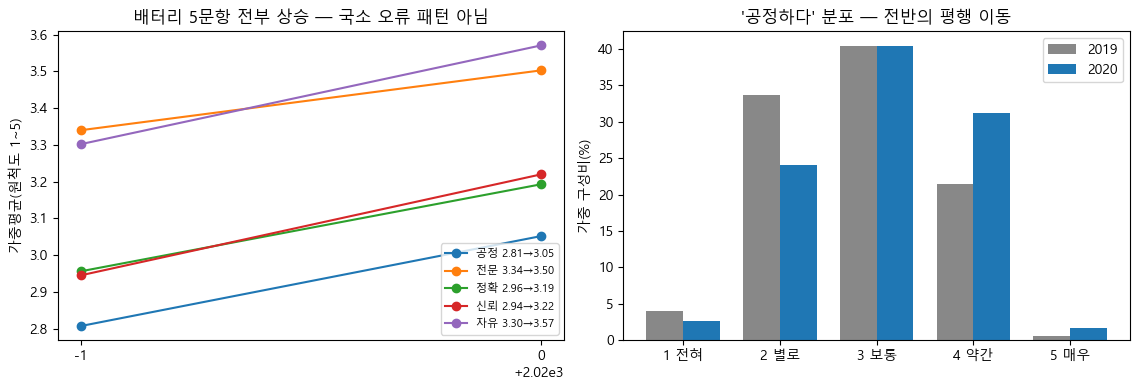

In [4]:
kr = {"cred_fair": "공정", "cred_professional": "전문", "cred_accurate": "정확",
      "cred_trustworthy": "신뢰", "press_free": "자유"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))

# (좌) 5문항 slope — 2019 → 2020
for ind in kr:
    m19 = float(dists.loc[(dists["year"] == 2019) & (dists["indicator"] == ind), "mean_wt"].iloc[0])
    m20 = float(dists.loc[(dists["year"] == 2020) & (dists["indicator"] == ind), "mean_wt"].iloc[0])
    axes[0].plot([2019, 2020], [m19, m20], "o-", label=f"{kr[ind]} {m19:.2f}→{m20:.2f}")
axes[0].set_xticks([2019, 2020])
axes[0].set_ylabel("가중평균(원척도 1~5)")
axes[0].set_title("배터리 5문항 전부 상승 — 국소 오류 패턴 아님")
axes[0].legend(fontsize=8)

# (우) 공정하다 분포 이동
d19 = dists.loc[(dists["year"] == 2019) & (dists["indicator"] == "cred_fair")].iloc[0]
d20 = dists.loc[(dists["year"] == 2020) & (dists["indicator"] == "cred_fair")].iloc[0]
x = np.arange(5); w = 0.38
axes[1].bar(x - w/2, [d19[f"p{k}"] for k in range(1, 6)], w, label="2019", color="#888")
axes[1].bar(x + w/2, [d20[f"p{k}"] for k in range(1, 6)], w, label="2020", color="#1f77b4")
axes[1].set_xticks(x); axes[1].set_xticklabels(["1 전혀", "2 별로", "3 보통", "4 약간", "5 매우"])
axes[1].set_ylabel("가중 구성비(%)")
axes[1].set_title("'공정하다' 분포 — 전반의 평행 이동")
axes[1].legend()
fig.tight_layout(); plt.show()

### **Decision Box ② — 계단의 판정: 왜 '실재 + 원인 분해 불가 각주'에서 멈추는가**

**기준: 배제 가설과 잔여 교란을 어떻게 보고 언어로 옮기는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 코로나19 효과로 귀속 | "팬데믹 정보수요가 신뢰를 올렸다"로 단정 | ❌ 같은 해에 실사대행사도 바뀜(한국갤럽→칸타코리아) — 두 요인이 완전 교락(confounded), 관측 자료로 분리 불가 |
| (b) house effect로 귀속 | "조사기관 변경의 인공물"로 단정 | ❌ 마찬가지로 분리 불가 + 국제적으로 2020년 신뢰 상승이 광범위 관찰(Reuters DNR 40개국 중 35개국) — 기관 단독 귀속은 과잉 |
| (c) **실재 확인 + 분해 불가 각주** | 계단은 공식 통계 실재(가설 5종 배제), 원인 귀속만 유보 | ✅ **채택** — 2020 보고서 스스로 "금년도 자료의 특성일 수 있음"(p.28) 신중 해석. 인용 시 **원인 각주 의무**(p6-pdf-structure §4-a 표준문구) |

**배제된 가설(원자료·코드북 검증, kpf-revalidation §2.1)**: 문항 워딩(라벨 원문 동일) · 척도/특수코드(2020 값 라벨의 2.5/5.5/9는 실데이터 0건) · 조사 모드(둘 다 가구방문 태블릿 대면) · 조사 시기(둘 다 6~7월) · 가중치 산출(wt1↔wt2 최대차 0.011) — **다섯 가설 전부 배제**.

## **4. [실행] C. 파이프라인 재현 대조 — `cred_mean` 7개년 ±0.001**

마지막 연결 고리: 이 노트북의 재계산(공식 WT)과 파이프라인 산출(`wt_year_eq`, eda-overview §1-③)이 같은가. `wt_year_eq`는 연도 내에서 WT의 상수배이므로 **연도 내 가중평균은 수학적으로 동일**해야 한다 — 어긋나면 정규화 구현의 버그다. `R.section_c_reproduce()`는 불일치 시 assert로 즉시 실패한다.

In [5]:
for m in R.section_c_reproduce(levels):
    print(" ", m)
print("\ncred_mean 재현 대조 7/7 PASS — wt_year_eq 정규화가 연도 내 평균을 보존한다")

  2019: 재검증 3.034 vs 파이프라인 3.034 → PASS
  2020: 재검증 3.249 vs 파이프라인 3.249 → PASS
  2021: 재검증 3.305 vs 파이프라인 3.305 → PASS
  2022: 재검증 3.211 vs 파이프라인 3.211 → PASS
  2023: 재검증 3.190 vs 파이프라인 3.190 → PASS
  2024: 재검증 3.176 vs 파이프라인 3.176 → PASS
  2025: 재검증 3.390 vs 파이프라인 3.390 → PASS

cred_mean 재현 대조 7/7 PASS — wt_year_eq 정규화가 연도 내 평균을 보존한다


## **5. [입증] 검증 셀 — 공식 보고서 공표치 ↔ 재계산, 전 셀 assert**

kpf-revalidation §1.1·§1.2의 공표치를 상수로 박아 재계산과 대조한다. 평균은 공표치가 소수 둘째 자리이므로 허용오차 ±0.005(반올림 경계), 비율은 소수 첫째 자리이므로 ±0.05로 판정한다.

In [6]:
# 공식 보고서 공표치(kpf-revalidation §1.1·§1.2 — 1차 원전에서 전사)
OFFICIAL_BATTERY = {  # (연도, 지표) → 5점 평균
    (2019, "cred_fair"): 2.81, (2019, "cred_professional"): 3.34,
    (2019, "cred_accurate"): 2.96, (2019, "cred_trustworthy"): 2.95,
    (2019, "press_free"): 3.30,
    (2020, "cred_fair"): 3.05, (2020, "cred_professional"): 3.50,
    (2020, "cred_accurate"): 3.19, (2020, "cred_trustworthy"): 3.22,
    (2020, "press_free"): 3.57,
}
OFFICIAL_OVERALL = {2023: (3.27, 37.8), 2024: (3.36, 45.5), 2025: (3.44, 49.0)}

n_cells = 0
# (a) 배터리 10셀 (5문항 × 2개년)
for (y, ind), official in OFFICIAL_BATTERY.items():
    got = float(dists.loc[(dists["year"] == y) & (dists["indicator"] == ind), "mean_wt"].iloc[0])
    assert abs(got - official) <= 0.0051, f"배터리 불일치 {y} {ind}: {got:.3f} vs 공표 {official}"
    n_cells += 1
print(f"(a) 언론 인식 배터리 {n_cells}셀(5문항×2개년) — 공표치와 반올림 자리까지 전 셀 일치 PASS")

# (b) 뉴스 전반 신뢰 평균·비율 6셀 (2023~2025)
for y, (mean_off, pct_off) in OFFICIAL_OVERALL.items():
    row = levels.loc[levels["year"] == y].iloc[0]
    assert abs(float(row["overall_mean_wt"]) - mean_off) <= 0.0051, f"전반 평균 불일치 {y}"
    assert abs(float(row["overall_pct45_wt"]) - pct_off) <= 0.051, f"전반 비율 불일치 {y}"
    print(f"(b) {y}: 전반 평균 {row['overall_mean_wt']:.3f}↔{mean_off} · "
          f"'신뢰한다' {row['overall_pct45_wt']:.1f}%↔{pct_off}% PASS")

# (c) cred_mean 7개년 ↔ 파이프라인 기준값(±0.001) — §4에서 assert 완료, 수치 재확인
for y in R.YEARS:
    got = float(levels.loc[levels["year"] == y, "cred_mean_wt"].iloc[0])
    assert abs(got - R.PIPELINE_CRED_MEAN[y]) <= 0.001
print(f"(c) cred_mean 7개년 ↔ 파이프라인(eda-overview §1-③) ±0.001 전부 PASS")

# (d) 2019 가중치 민감도 — wt1↔wt2 최대차 ≤ 0.011 (가중치 가설 배제 근거)
diffs = []
for n in notes:
    a = float(n.split("wt1 가중평균=")[1].split(" /")[0])
    b = float(n.split("wt2 가중평균=")[1].split(" /")[0])
    diffs.append(abs(a - b))
assert max(diffs) <= 0.0111, f"가중치 민감도 초과: {max(diffs):.3f}"
print(f"(d) 2019 wt1↔wt2 최대차 {max(diffs):.3f} ≤ 0.011 — 가중치 가설 배제 PASS")

print(f"\n검증 (a)~(d) 전부 PASS — 총 {n_cells + 6 + 7}셀 + 민감도 {len(diffs)}건")

(a) 언론 인식 배터리 10셀(5문항×2개년) — 공표치와 반올림 자리까지 전 셀 일치 PASS
(b) 2023: 전반 평균 3.272↔3.27 · '신뢰한다' 37.8%↔37.8% PASS
(b) 2024: 전반 평균 3.360↔3.36 · '신뢰한다' 45.5%↔45.5% PASS
(b) 2025: 전반 평균 3.436↔3.44 · '신뢰한다' 49.0%↔49.0% PASS
(c) cred_mean 7개년 ↔ 파이프라인(eda-overview §1-③) ±0.001 전부 PASS
(d) 2019 wt1↔wt2 최대차 0.011 ≤ 0.011 — 가중치 가설 배제 PASS

검증 (a)~(d) 전부 PASS — 총 23셀 + 민감도 3건


**관찰 — 자격등급 갱신(이 노트북이 바꾼 것, kpf-revalidation §0)**:

| 항목 | 재검증 전 | 재검증 후 |
|------|----------|----------|
| 원척도 절대수준(평균·비율) | 미검증 — 인용 신중 | ✅ **확정 인용**("KPF 원자료, 20XX" 출처) |
| 2019→2020 상승 | 방향만 | ✅ **검증된 결과 + 원인 각주 의무**(§4-a 표준문구) |
| 잠재척도 SD 크기(+0.671 등) | 방향만 | ⚠️ **방향만 유지** — 모형 의존, 재검증 대상 아님 |
| "유의한 추세" 표현 | 금지 | ❌ **금지 유지**(MK p=0.381) |

시장조사 신뢰 시계열 혼용(data-spec §6 항목 2)도 함께 규명됐다: "2021 3.48"은 **이용 매체** 신뢰(3.479), "2023 3.27"은 **전반**(3.272), "2025 49.0%"는 전반 '신뢰한다' **비율** — 문항과 형식이 뒤섞인 인용이었다. 이후 모든 인용은 문항·형식을 병기한다(manuscript 표 1 주석).

## **6. 종합 — 게이트가 해소됐다**

### **연구질문 답**

- **Q1 (공식 통계 재현)** — 그렇다. 배터리 10셀 + 전반 신뢰 6셀이 공표치와 반올림 자리까지 일치하고(§5 (a)(b)), `cred_mean` 7개년이 파이프라인 산출과 ±0.001 이내(§5 (c)). 변수 매핑·특수코드·가중치의 3대 오류원이 원전 수준에서 배제됐다.
- **Q2 (계단의 실재)** — 실재한다. 배터리 5문항 전부가 공식 통계에서 상승했고(§3 좌), 분포는 전반의 평행 이동(§3 우), 워딩·척도·모드·시기·가중치 다섯 가설은 원자료 검증으로 배제(DB②). 남는 것은 실사대행사 변경+코로나19의 교락 — **원인 귀속 분해 불가, 인용 시 각주 의무**.
- **Q3 (자격등급)** — 원척도 절대수준·2019→2020 상승이 **검증된 결과로 승격**(후자는 각주 의무), 잠재척도 SD 크기는 '방향만' 유지, "유의한 추세"는 금지 유지 — 이 등급표가 `p6-pdf-structure` §3과 `manuscript.md`의 모든 수치 인용을 지배한다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 1 | 대조 기준 선택(DB① — 공식 공표치) | 채택 |
| 2 | 절대수준 재계산(원척도·공식 WT) | 표 산출 |
| 3 | 계단 진단(라벨·분포·민감도 + DB②) | 실재·가설 5종 배제 |
| 4 | 파이프라인 재현 대조 | 7/7 PASS |
| 5 | 공표치 전 셀 assert + 등급 갱신 | **전 셀 PASS** |

### **다음**

- 이 판정을 상속하는 곳: `10`·`11`·`20`~`30`의 게이트 문구(해소됨), [`p6-pdf-structure.md`](../docs/report/p6-pdf-structure.md) §3 인용 수치표, [`manuscript.md`](../docs/report/manuscript.md) 표 1(F1).
- 잔여 게이트 2건(매체별 이용률 정의 대조 · 뉴스회피 72% 출처)은 해당 수치를 보고서에 **싣지 않는 방침**으로 해소 불요(kpf-revalidation §3).

**재현 경로**: `python src/kpf_revalidation.py` (CSV 재생성물 → `data/interim/revalidation/`, gitignore).